# STAT.DATATHON-2026 — дескриптивная аналитика датасетов

Воспроизводимый анализ синтетических микроданных БНС АСПР РК за 2021–2024 годы.

**Что делает ноутбук**

1. Распаковывает архив по частям и конвертирует все 236 CSV в parquet (4,68 ГБ → ~300 МБ).
2. Строит инвентаризацию форм и карту дрейфа схемы между годами.
3. Считает индикаторы рынка труда по T-001.
4. Считает доходы, расходы и жилищные условия по D-серии.
5. Показывает, почему формы 1-Т и 2-Т нельзя использовать в абсолютных величинах без справочника KCP.
6. Выгружает агрегаты в CSV и JSON для дашборда и слайдов.

**Требования:** Python 3.10+, `duckdb`, `pandas`, `matplotlib`. Оперативной памяти достаточно 4 ГБ: тяжёлые файлы никогда не грузятся в память целиком, всё считает DuckDB потоково.

**Дедлайны:** Результат 1 — 30.09, Результат 2 — 07.10, финальная работа — 12.10, финал — 20.10.

## 0. Настройка

In [1]:
# !pip install duckdb pandas matplotlib -q

import json, os, subprocess, time, zipfile, glob
import duckdb, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

ZIP  = os.environ.get("DATATHON_ZIP", "../data/synthetic_microdata_2021-2024_20260921.zip")  # архив организатора
ROOT = "synthetic_microdata_2021-2024_20260921"       # корневая папка внутри архива
PQ   = "../data/pq"       # сюда лягут parquet-файлы (общие со скриптами src/)
TMP  = "../data/tmp_csv"  # временная распаковка, очищается на лету
AGG  = "../data/agg"      # агрегаты ноутбука (эталонные — в outputs/aggregates)

for d in (PQ, TMP, AGG):
    os.makedirs(d, exist_ok=True)

con = duckdb.connect()
con.execute("PRAGMA memory_limit='1800MB'")

pd.set_option("display.width", 200)
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25, "font.size": 10,
})
BLUE, ORANGE, GREEN, RED, GREY = "#1f6feb", "#d9822b", "#2e8b6f", "#c0392b", "#8a9099"

## 1. Конвертация архива в parquet

CSV читается медленно и занимает 4,68 ГБ. Parquet со сжатием zstd даёт около 300 МБ, и после этого любой запрос по годовой 1-Т (8,5 млн строк) отрабатывает за секунды.

Две детали, без которых конвертация ломается:

* в файле T-001 за 2022 год на строке 26332 внутри поля есть запятая в кавычках, поэтому нужен явный `quote='"'`;
* `sample_size=-1` заставляет DuckDB просмотреть файл целиком при определении типов, иначе редкие нечисловые значения обрезаются.

In [2]:
def convert(forms=None, force=False):
    """Распаковывает по одному файлу, пишет parquet, сразу удаляет CSV."""
    z = zipfile.ZipFile(ZIP)
    manifest = json.loads(z.read(f"{ROOT}/MANIFEST.json"))
    opts = "quote='\"', sample_size=-1"
    for r in manifest:
        if forms and r["form"] not in forms:
            continue
        key = r["path"].replace("/", "__").rsplit(".", 1)[0]
        out = f"{PQ}/{key}.parquet"
        if os.path.exists(out) and not force:
            continue
        t0 = time.time()
        z.extract(f"{ROOT}/{r['path']}", TMP)
        src = f"{TMP}/{ROOT}/{r['path']}"
        try:
            con.execute(f"copy (select * from read_csv_auto('{src}', {opts})) "
                        f"to '{out}' (format parquet, compression zstd)")
        except Exception as e:
            print("fallback all_varchar:", key, str(e)[:70])
            con.execute(f"copy (select * from read_csv_auto('{src}', {opts}, all_varchar=true)) "
                        f"to '{out}' (format parquet, compression zstd)")
        os.remove(src)
        print(f"{key:46} {r['rows_synthetic']:>10,} строк  "
              f"{os.path.getsize(out)/1e6:6.1f} МБ  {time.time()-t0:5.1f}с", flush=True)

convert()   # около 4 минут на один поток
print("parquet:", round(sum(os.path.getsize(f) for f in glob.glob(f"{PQ}/*.parquet"))/1e6), "МБ")

parquet: 314 МБ


## 2. Инвентаризация и дрейф схемы

Первое, что стоит показать жюри: архив неоднороден. Одна и та же форма меняет названия колонок, кодировку региона и число признаков от года к году.

In [3]:
rows = []
for f in sorted(glob.glob(f"{PQ}/*.parquet")):
    key = os.path.basename(f)[:-8]
    form = key.split("__")[0]
    n = con.execute(f"select count(*) from '{f}'").fetchone()[0]
    cols = [c[0] for c in con.execute(f"describe select * from '{f}'").fetchall()]
    rows.append(dict(form=form, table=key, rows=n, cols=len(cols), mb=os.path.getsize(f)/1e6))

inv = pd.DataFrame(rows)
summary = inv.groupby("form").agg(files=("table", "size"), rows=("rows", "sum"), mb=("mb", "sum")).round(1)
summary["rows"] = summary["rows"].map("{:,}".format)
display(summary)

,files,rows,mb
form,,,
1t_god,4,"30,025,899",126.3
1t_kv,16,"24,480,242",82.1
2t,4,"7,328,814",49.0
d002,8,"95,542",1.6
d004,192,"8,612,484",30.4
d006,4,"46,743",1.1
d008,4,"169,059",1.2
t001,4,"1,885,110",22.6


In [4]:
# Что именно меняется в форме 1-Т между годами
god = {2021: "1t_god__2021__2021_1t_god", 2022: "1t_god__2022__2022_1t_god",
       2023: "1t_god__2023__2023_1t_god", 2024: "1t_god__2024__sr_1t_god_12_2024"}
for y, t in god.items():
    f = f"{PQ}/{t}.parquet"
    if not os.path.exists(f):     # имена файлов зависят от того, как их назвал организатор
        f = glob.glob(f"{PQ}/1t_god*{y}*.parquet")[0]
    cols = [c[0] for c in con.execute(f"describe select * from '{f}'").fetchall()]
    print(y, len(cols), "колонок:", ", ".join(cols))

2021 16 колонок: ID, KCP, KATO, OKED, KZ, SPVRP, SVNO, SSFZP, GSUORP, SVR, SPNR, SP, SKRAB, SVDOB, SSSCHR, GR1
2022 18 колонок: ID, KATO, RMONTH, RYEAR, KCP, GR1, KZ, SPVRP, SVNO, SSFZP, GSUORP, SVR, SPNR, SP, OKED, SKRAB, SVDOB, SSSCHR
2023 19 колонок: RMONTH, RYEAR, KCP, GR1, SSFZP, GSUORP, SPTM1, SKRAB, SSSCHR, SPNR, KZ, SVDOB, SVNO, KATO, OKED, SPVRP, SVR, SP, ID
2024 30 колонок: RYEAR, KCP, VAL_NUM, SSFZP, SPTM1, SKRAB, GSUORP, SSSCHR, SPNR, SVNO, KZ, SVDOB, KATO1, OKED1, OKED2, SVR, SPVRP, SP, KPOP, SPTM, OKED, AKT, GSGTPE, KATO, KFS, SPVD, KOPF, KSE, KRP, ID


Ключевые ловушки, которые видно из вывода выше:

| Что | 2021–2023 | 2024 |
|---|---|---|
| Колонка со значением | `GR1` | `VAL_NUM` |
| Колонка региона | `KATO` (2 знака) | `KATO1` (9 знаков) |
| ОКЭД | 2 знака, 83 кода | 4–5 знаков, 539 кодов |
| Колонок в годовой 1-Т | 16 / 18 / 19 | 30 |

Плюс административная реформа: в 2021 году в данных 17 регионов, с 2022 — 20 (добавились Абай `10`, Жетісу `33`, Ұлытау `62`). Любой ряд по регионам за 2021–2024 разрывается на этом месте.

In [5]:
def regions(form_glob, col="TE"):
    out = {}
    for y in (2021, 2022, 2023, 2024):
        f = glob.glob(f"{PQ}/{form_glob}__{y}__*.parquet")[0]
        out[y] = sorted(str(x[0]) for x in con.execute(f"select distinct {col} from '{f}'").fetchall())
    return out

reg = regions("d008")
for y, v in reg.items():
    print(y, len(v), v)
print("\nпоявились с 2022:", sorted(set(reg[2024]) - set(reg[2021])))

2021 17 ['11', '15', '19', '23', '27', '31', '35', '39', '43', '47', '55', '59', '61', '63', '71', '75', '79']
2022 20 ['10', '11', '15', '19', '23', '27', '31', '33', '35', '39', '43', '47', '55', '59', '61', '62', '63', '71', '75', '79']
2023 20 ['10', '11', '15', '19', '23', '27', '31', '33', '35', '39', '43', '47', '55', '59', '61', '62', '63', '71', '75', '79']
2024 20 ['10', '11', '15', '19', '23', '27', '31', '33', '35', '39', '43', '47', '55', '59', '61', '62', '63', '71', '75', '79']

появились с 2022: ['10', '33', '62']


## 3. Рынок труда: T-001

Форма обследования занятости — самая пригодная к анализу часть архива: колонки самоописывающиеся, около 470 тыс. наблюдений в год.

Смысл переменных:

* `ZAN_RABOTA` — занятость (1 = работал);
* `PSK_RABOTA` — искал ли работу;
* `ORB_TRDDOG` — наличие письменного трудового договора (2 = нет), заполнена только у наёмных работников;
* `DH_POLRESP` — пол, `DH_OBRAZOV` — образование, `vosr` — возраст, `TE` — регион.

In [6]:
T = {y: glob.glob(f"{PQ}/t001__{y}__*.parquet")[0] for y in (2021, 2022, 2023, 2024)}

labour = pd.concat([con.execute(f"""
  select {y} as yr, count(*) as n,
    100.0*sum(case when ZAN_RABOTA=1 then 1 else 0 end)/count(*)                       as emp_rate,
    100.0*sum(case when PSK_RABOTA=1 then 1 else 0 end)/count(*)                       as searching,
    sum(case when ORB_TRDDOG is not null then 1 else 0 end)                            as contract_base,
    100.0*sum(case when ORB_TRDDOG=2 then 1 else 0 end)
          / nullif(sum(case when ORB_TRDDOG is not null then 1 else 0 end),0)          as no_contract,
    100.0*sum(case when ZAN_RABOTA=1 and DH_POLRESP=1 then 1 else 0 end)
          / sum(case when DH_POLRESP=1 then 1 else 0 end)                              as emp_male,
    100.0*sum(case when ZAN_RABOTA=1 and DH_POLRESP=2 then 1 else 0 end)
          / sum(case when DH_POLRESP=2 then 1 else 0 end)                              as emp_female
  from '{f}'""").df() for y, f in T.items()])

labour.to_csv(f"{AGG}/labour_by_year.csv", index=False)
labour.round(2)

,yr,n,emp_rate,searching,contract_base,no_contract,emp_male,emp_female
0,2021,472456,67.64,3.68,229313.0,3.47,71.47,64.36
0,2022,467667,67.18,3.62,228083.0,3.46,71.91,63.10
0,2023,475635,66.35,3.64,229021.0,3.02,70.92,62.47
0,2024,469352,65.86,3.51,228016.0,5.18,69.60,62.66


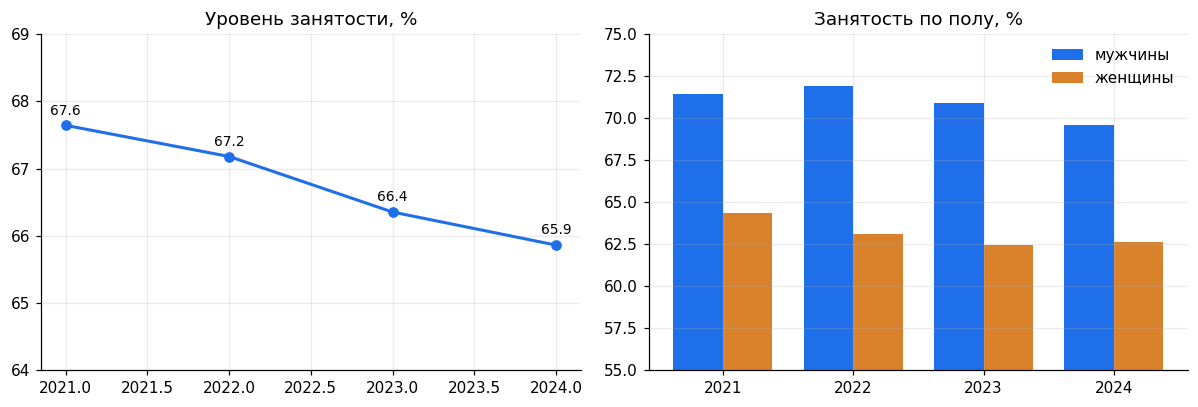

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(labour.yr, labour.emp_rate, "o-", color=BLUE, lw=2)
ax[0].set_title("Уровень занятости, %"); ax[0].set_ylim(64, 69)
for x, y in zip(labour.yr, labour.emp_rate):
    ax[0].annotate(f"{y:.1f}", (x, y), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=9)

w = .38
ax[1].bar(labour.yr - w/2, labour.emp_male, w, label="мужчины", color=BLUE)
ax[1].bar(labour.yr + w/2, labour.emp_female, w, label="женщины", color=ORANGE)
ax[1].set_ylim(55, 75); ax[1].set_title("Занятость по полу, %"); ax[1].legend(frameon=False)
ax[1].xaxis.set_major_locator(mticker.FixedLocator(labour.yr))
plt.tight_layout(); plt.show()

Занятость снижается монотонно, с 67,6% до 65,9% за четыре года. Гендерный разрыв держится около 7 п.п. и не сокращается — это само по себе тема для проекта.

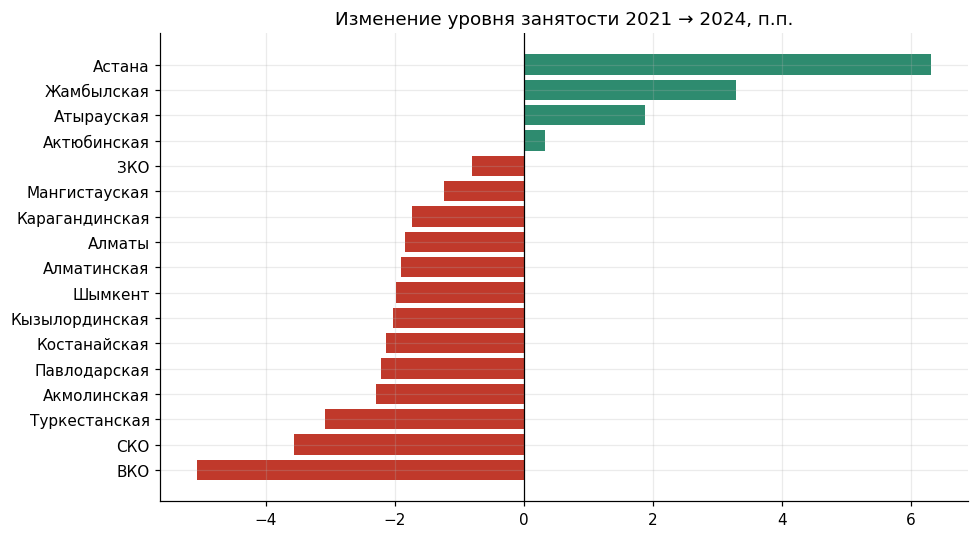

In [8]:
KATO = {"10":"Абай","11":"Акмолинская","15":"Актюбинская","19":"Алматинская","23":"Атырауская",
        "27":"ЗКО","31":"Жамбылская","33":"Жетісу","35":"Карагандинская","39":"Костанайская",
        "43":"Кызылординская","47":"Мангистауская","55":"Павлодарская","59":"СКО","61":"Туркестанская",
        "62":"Ұлытау","63":"ВКО","71":"Астана","75":"Алматы","79":"Шымкент"}
# Сопоставление восстановлено по кодам КАТО и требует сверки с официальным справочником.

parts = []
for y, f in T.items():
    d = con.execute(f"""select cast(TE as varchar) as reg,
        100.0*sum(case when ZAN_RABOTA=1 then 1 else 0 end)/count(*) as v from '{f}' group by 1""").df()
    d["yr"] = y; parts.append(d)

emp_reg = pd.concat(parts).pivot(index="reg", columns="yr", values="v")
emp_reg["change"] = emp_reg[2024] - emp_reg[2021]
emp_reg.index = [KATO.get(i, i) for i in emp_reg.index]
emp_reg.sort_values("change").round(1).to_csv(f"{AGG}/employment_by_region.csv")

d = emp_reg.dropna(subset=["change"]).sort_values("change")
plt.figure(figsize=(9, 5))
plt.barh(d.index, d["change"], color=[RED if v < 0 else GREEN for v in d["change"]])
plt.axvline(0, color="black", lw=.8)
plt.title("Изменение уровня занятости 2021 → 2024, п.п."); plt.tight_layout(); plt.show()

Средняя цифра по стране прячет расхождение: Астана прибавила 6,3 п.п., а ВКО и СКО потеряли 5,1 и 3,6 п.п. Это уже готовая гипотеза для Результата 2.

In [9]:
parts = []
for y, f in T.items():
    d = con.execute(f"""select cast(TE as varchar) as reg,
        100.0*sum(case when ORB_TRDDOG=2 then 1 else 0 end)
        / nullif(sum(case when ORB_TRDDOG is not null then 1 else 0 end),0) as v,
        sum(case when ORB_TRDDOG is not null then 1 else 0 end) as base
        from '{f}' group by 1""").df()
    d["yr"] = y; parts.append(d)

inf = pd.concat(parts)
piv = inf.pivot(index="reg", columns="yr", values="v")
piv.index = [KATO.get(i, i) for i in piv.index]
piv.round(1).sort_values(2024, ascending=False).to_csv(f"{AGG}/informality_by_region.csv")
piv.round(1).sort_values(2024, ascending=False).head(8)

yr,2021,2022,2023,2024
Алматинская,6.3,5.4,4.8,40.7
Туркестанская,8.0,16.8,15.3,12.9
Жамбылская,16.5,12.9,9.6,10.2
Мангистауская,1.2,1.2,1.6,4.3
Абай,NaN,2.1,1.6,3.2
Жетісу,NaN,2.7,2.1,3.1
Кызылординская,5.1,6.0,2.2,3.0
ВКО,2.0,1.9,1.5,2.8


### Аномалия, которую нельзя игнорировать

Алматинская область: 6,3 → 5,4 → 4,8 → **40,7%**. База ответов при этом стабильна (около 13 тыс. заполненных значений), то есть это не эффект выборки, а почти наверняка сбой генератора синтетики.

Если в проекте берётся тема неформальной занятости, этот регион нужно либо исключить с явной оговоркой, либо сделать отдельным кейсом о контроле качества синтетических данных. Второй вариант сильнее играет на критерий «методологическая проработанность».

In [10]:
chk = inf[inf.reg == "19"][["yr", "v", "base"]].rename(columns={"v": "без договора, %", "base": "база ответов"})
display(chk.round(1))

no_19 = []
for y, f in T.items():
    v = con.execute(f"""select 100.0*sum(case when ORB_TRDDOG=2 then 1 else 0 end)
        / nullif(sum(case when ORB_TRDDOG is not null then 1 else 0 end),0)
        from '{f}' where TE <> 19""").fetchone()[0]
    no_19.append((y, round(v, 2)))
print("без Алматинской области:", no_19)

,yr,"без договора, %",база ответов
1,2021,6.3,22733.0
7,2022,5.4,13743.0
0,2023,4.8,12768.0
0,2024,40.7,13204.0


без Алматинской области: [(2021, 3.16), (2022, 3.34), (2023, 2.91), (2024, 3.0)]


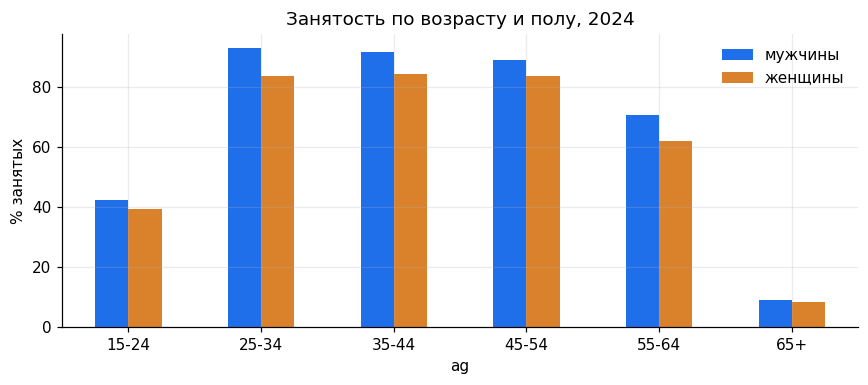

In [11]:
# Занятость по возрасту и полу, 2024 — проверка правдоподобия синтетики
age = con.execute(f"""
 select case when vosr<25 then '15-24' when vosr<35 then '25-34' when vosr<45 then '35-44'
             when vosr<55 then '45-54' when vosr<65 then '55-64' else '65+' end as ag,
        DH_POLRESP as sex, count(*) as n,
        100.0*sum(case when ZAN_RABOTA=1 then 1 else 0 end)/count(*) as emp
 from '{T[2024]}' where vosr >= 15 group by 1,2 order by 1,2""").df()
age.to_csv(f"{AGG}/employment_by_age_sex.csv", index=False)

p = age.pivot(index="ag", columns="sex", values="emp")
p.plot(kind="bar", color=[BLUE, ORANGE], rot=0, figsize=(8, 3.6))
plt.legend(["мужчины", "женщины"], frameon=False); plt.ylabel("% занятых")
plt.title("Занятость по возрасту и полу, 2024"); plt.tight_layout(); plt.show()

Возрастной профиль ведёт себя как настоящий: пик в 25–34 года, обвал после 65 лет, женская кривая ниже мужской во всех группах кроме старшей. Это хороший аргумент в пользу того, что синтетика сохраняет внутреннюю структуру.

### Ограничение по NEET

Посчитать классический NEET нельзя: в выгрузке 40 колонок из примерно 154, и признака «учится» среди них нет. Доля молодёжи 15–28 лет, которая не работает и не ищет работу, составляет около 44%, но туда попадают студенты. Индикатор нужно либо переопределять, либо запрашивать недостающие колонки у организаторов.

## 4. Домохозяйства: D-серия

Четыре формы соединяются по ключу `NOMER` (или `TE` + `K`), а внутри домохозяйства по `NOMP`:

* `d008` — состав домохозяйства,
* `d006` — жильё и благоустройство (247 колонок),
* `d004` — расходы и доходы поквартально,
* `d002` — субъективные оценки.

In [12]:
r = glob.glob(f"{PQ}/d008__2024__*.parquet")[0]
h = glob.glob(f"{PQ}/d006__2024__*.parquet")[0]
s = glob.glob(f"{PQ}/d002__2024__subject.parquet")[0]
e = glob.glob(f"{PQ}/d004__2024__1kv__kv_vopr1.parquet")[0]

for name, f in [("жильё d006", h), ("оценки d002", s), ("расходы d004", e)]:
    q = con.execute(f"""select
        (select count(distinct NOMER) from '{r}') as roster,
        (select count(distinct NOMER) from '{f}') as other,
        (select count(*) from (select distinct NOMER from '{r}'
                               intersect select distinct NOMER from '{f}')) as common""").fetchone()
    print(f"{name:14} реестр={q[0]}  таблица={q[1]}  пересечение={q[2]}")

жильё d006     реестр=12000  таблица=11704  пересечение=11704
оценки d002    реестр=12000  таблица=11931  пересечение=11931


расходы d004   реестр=12000  таблица=11958  пересечение=11958


Стыковка чистая, «сирот» нет.

Осторожно с ключами: `K` — это **не** номер домохозяйства, у него всего два значения. Домохозяйство внутри года однозначно определяется полем `NOMER`, первые четыре знака которого — год.

### Панели между годами нет

`NOMER` содержит год, поэтому напрямую годы не сопоставить. Проверим косвенно: если бы порядковые номера сохранялись, домохозяйство № N в 2023 и 2024 году было бы из одного региона. Совпадение региона должно тогда быть близко к 100%, а при случайной перенумерации — около 5% (1 из 20 регионов).

In [13]:
a = glob.glob(f"{PQ}/d008__2023__*.parquet")[0]
b = glob.glob(f"{PQ}/d008__2024__*.parquet")[0]
print(con.execute(f"""
 with A as (select distinct cast(NOMER as varchar) as n, TE from '{a}'),
      B as (select distinct cast(NOMER as varchar) as n, TE from '{b}')
 select count(*) as matched_ids,
        round(100.0*sum(case when A.TE=B.TE then 1 else 0 end)/count(*), 1) as same_region_pct
 from A join B on substr(A.n,5)=substr(B.n,5)""").df())

   matched_ids  same_region_pct
0        12000              5.4


Совпадение региона 5,4% — это ровно случайный уровень. Номера перевыдаются каждый год, панели нет, анализ возможен только повторными срезами.

### Что такое `K`: скрытый признак «город — село»

Поле `K` принимает два значения и отсутствует в описании. Сравним группы по независимым характеристикам — если это городская и сельская подвыборки, разница должна быть систематической и в ожидаемую сторону.

In [14]:
h = glob.glob(f"{PQ}/d006__2024__*.parquet")[0]
r = glob.glob(f"{PQ}/d008__2024__*.parquet")[0]
t = T[2024]
amen = " + ".join([f"case when cast(U{i} as varchar)='1' then 1 else 0 end" for i in range(1, 43)])

house = con.execute(f"""select K, count(*) as hh, avg(try_cast(OB_PL as double)) as area,
    avg({amen}) as amenities from '{h}' group by 1 order by 1""").df()
size = con.execute(f"select K, avg(KOL_CHL) as hh_size from '{r}' group by 1 order by 1").df()
work = con.execute(f"""select K, 100.0*sum(case when ZAN_RABOTA=1 then 1 else 0 end)/count(*) as emp,
    100.0*sum(case when ORB_TRDDOG=2 then 1 else 0 end)
      / nullif(sum(case when ORB_TRDDOG is not null then 1 else 0 end),0) as no_contract
    from '{t}' group by 1 order by 1""").df()

display(house.merge(size, on="K").merge(work, on="K").round(2))

,K,hh,area,amenities,hh_size,emp,no_contract
0,1,6375,65.12,12.74,4.21,64.41,2.83
1,2,5329,82.41,11.93,4.90,66.95,7.18


Картина однозначная и согласуется сама с собой по трём независимым формам:

| Признак | K = 1 | K = 2 |
|---|---|---|
| Площадь жилья, м² | 65,1 | 82,4 |
| Удобств из 42 | 12,7 | 11,9 |
| Размер домохозяйства | 4,21 | 4,90 |
| Работа без договора, % | 2,8 | 7,2 |

Меньше площадь, больше благоустройства, меньше семья и втрое ниже неформальность — это город. Больше дом, меньше коммуникаций, больше семья и высокая неформальность — это село.

Практический вывод: разрез «город — село» в данных **есть**, просто он не подписан. Это открывает целый класс тем, от жилищной депривации до сельской неформальной занятости, и сам факт восстановления смысла переменной — хороший материал для слайда по методологии. Направление кодировки (какое значение город, какое село) стоит подтвердить у организаторов.

### 4.1 Доходы и расходы

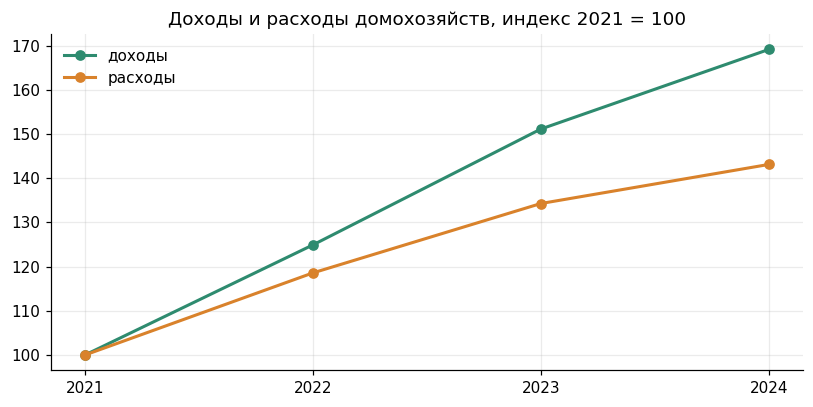

,доходы,расходы
2021,100.0,100.0
2022,124.9,118.6
2023,151.1,134.3
2024,169.2,143.1


In [15]:
# Доходы: вопрос 11 формы D-004, GR1 — трудовой доход по каждому члену домохозяйства
inc = []
for y in (2021, 2022, 2023, 2024):
    fs = glob.glob(f"{PQ}/d004__{y}__*kv__kv_vopr11.parquet")
    u = " union all ".join(f"select * from '{f}'" for f in fs)
    inc.append(con.execute(f"select {y} as yr, count(distinct NOMER) as hh, sum(GR1) as wage_inc from ({u})").df())
inc = pd.concat(inc)
inc["wage_per_hh_month"] = inc.wage_inc / inc.hh / 12
inc.to_csv(f"{AGG}/income_by_year.csv", index=False)

# Расходы: вопросы 1-7, все кварталы
sp = []
for y in (2021, 2022, 2023, 2024):
    row = {"yr": y}
    for v in range(1, 8):
        fs = glob.glob(f"{PQ}/d004__{y}__*kv__kv_vopr{v}.parquet")
        if not fs: continue
        u = " union all ".join(f"select try_cast(STOIMK as double) as s from '{f}'" for f in fs)
        row[f"q{v}"] = con.execute(f"select sum(s) from ({u})").fetchone()[0]
    sp.append(row)
sp = pd.DataFrame(sp).set_index("yr")
sp["total"] = sp.sum(axis=1)
sp.to_csv(f"{AGG}/spending_by_question.csv")

idx = pd.DataFrame({
    "доходы": (inc.wage_per_hh_month / inc.wage_per_hh_month.iloc[0] * 100).values,
    "расходы": (sp.total / sp.total.iloc[0] * 100).values,
}, index=[2021, 2022, 2023, 2024])

plt.figure(figsize=(7.5, 3.8))
plt.plot(idx.index, idx["доходы"], "o-", color=GREEN, lw=2, label="доходы")
plt.plot(idx.index, idx["расходы"], "o-", color=ORANGE, lw=2, label="расходы")
plt.legend(frameon=False); plt.title("Доходы и расходы домохозяйств, индекс 2021 = 100")
plt.xticks(idx.index); plt.tight_layout(); plt.show()
idx.round(1)

**Главная находка.** Доходы выросли на 69%, расходы на 43%. Разрыв в 26 п.п. за три года означает либо рост нормы сбережений, либо систематический недоучёт расходов, что в бюджетных обследованиях обычное дело.

Это хорошая гипотеза для Результата 2: проверить, у каких групп домохозяйств разрыв больше, и связан ли он с составом семьи, регионом или уровнем дохода.

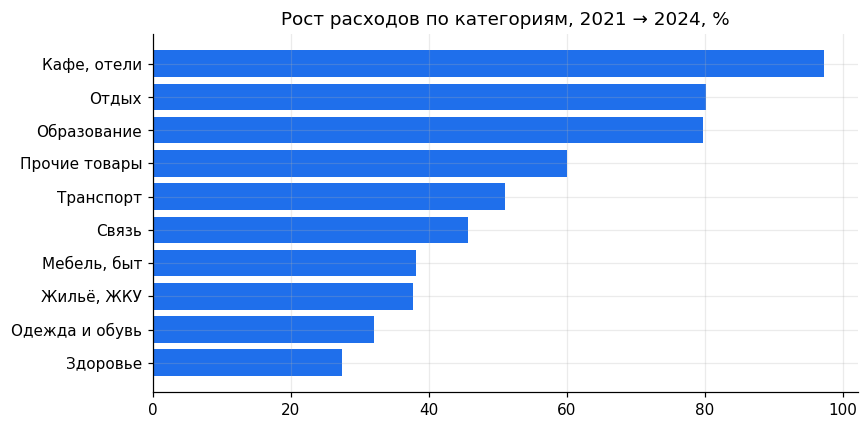

yr,2021,2022,2023,2024
Одежда и обувь,2.52,3.09,3.38,3.32
"Жильё, ЖКУ",2.03,2.32,2.54,2.80
"Мебель, быт",1.67,1.97,2.19,2.30
Прочие товары,1.36,1.66,1.95,2.17
Связь,1.24,1.47,1.69,1.81
Транспорт,0.97,1.11,1.27,1.47
Здоровье,0.87,0.94,1.08,1.11
Отдых,0.51,0.67,0.84,0.91
Образование,0.30,0.41,0.53,0.54
"Кафе, отели",0.16,0.22,0.28,0.31


In [16]:
# Расходы по категориям КИПЦ (первые два знака кода товара)
COICOP = {"01":"Продукты","03":"Одежда и обувь","04":"Жильё, ЖКУ","05":"Мебель, быт","06":"Здоровье",
          "07":"Транспорт","08":"Связь","09":"Отдых","10":"Образование","11":"Кафе, отели","12":"Прочие товары"}
rows = []
for y in (2021, 2022, 2023, 2024):
    fs = [f for v in range(1, 8) for f in glob.glob(f"{PQ}/d004__{y}__*kv__kv_vopr{v}.parquet")]
    u = " union all ".join(f"select cast(KODNU as varchar) as k, try_cast(STOIMK as double) as s from '{f}'" for f in fs)
    d = con.execute(f"select substr(k,1,2) as p, sum(s) as v from ({u}) where k is not null group by 1").df()
    d["yr"] = y; rows.append(d)

co = pd.concat(rows)
co = co[co.p.isin(COICOP)]
piv = co.pivot_table(index="p", columns="yr", values="v", fill_value=0)
piv.index = [COICOP[i] for i in piv.index]
piv = piv.sort_values(2024, ascending=False)
piv.to_csv(f"{AGG}/spending_by_coicop.csv")

growth = ((piv[2024] / piv[2021] - 1) * 100).sort_values()
plt.figure(figsize=(8, 4))
plt.barh(growth.index, growth.values, color=BLUE)
plt.title("Рост расходов по категориям, 2021 → 2024, %"); plt.tight_layout(); plt.show()
(piv / 1e9).round(2)

**Важное ограничение.** Категория «Продукты» здесь почти пустая: вопрос 1 формы D-004 охватывает непродовольственные товары, а дневник питания (форма D-001) в архив не включён. Классический коэффициент Энгеля посчитать нельзя, и это нужно проговорить явно, а не прятать.

### 4.2 Жилищные условия

In [17]:
rows = []
for y in (2021, 2022, 2023, 2024):
    f = glob.glob(f"{PQ}/d006__{y}__*.parquet")[0]
    amen = " + ".join([f"case when cast(U{i} as varchar)='1' then 1 else 0 end" for i in range(1, 43)])
    rows.append(con.execute(f"""select {y} as yr, count(*) as hh,
        avg(try_cast(OB_PL as double)) as area, avg(try_cast(KOL_K as double)) as rooms,
        avg(({amen})) as amenities_of_42 from '{f}'""").df())
hz = pd.concat(rows)
hz.to_csv(f"{AGG}/housing_by_year.csv", index=False)
hz.round(2)

,yr,hh,area,rooms,amenities_of_42
0,2021,11636,69.89,2.88,11.99
0,2022,11744,72.00,2.94,12.21
0,2023,11659,71.34,2.91,12.54
0,2024,11704,72.99,2.94,12.37


Динамики почти нет: площадь растёт с 69,9 до 73,0 кв. м, комнаты и удобства стоят на месте. Ценность формы не в тренде, а в разбросе — 42 признака благоустройства дают готовый индекс жилищной депривации для сравнения регионов и типов домохозяйств.

## 5. Формы предприятий 1-Т и 2-Т: почему абсолютные величины считать нельзя

Формы крупные (5,4 млн строк в годовой 1-Т за 2024 год, 52 289 предприятий), но записаны в длинном формате: одна строка — одно значение показателя `KCP`. Официального справочника `KCP` в архиве нет.

Ниже — попытка посчитать среднюю зарплату как отношение фонда оплаты труда к численности. Результат показывает, почему так делать нельзя.

In [18]:
G = {}
for y in (2021, 2022, 2023, 2024):
    f = glob.glob(f"{PQ}/1t_god__{y}__*.parquet")[0]
    cols = [c[0] for c in con.execute(f"describe select * from '{f}'").fetchall()]
    val = "VAL_NUM" if "VAL_NUM" in cols else "GR1"        # дрейф имени колонки
    G[y] = (f, val)

res = []
for y, (f, val) in G.items():
    res.append(con.execute(f"""select {y} as yr, count(distinct ID) as firms,
        sum(case when KCP=251401 then {val} end) as headcount,
        sum(case when KCP=252101 then {val} end) as payroll from '{f}'""").df())
ent = pd.concat(res)
ent["wage_per_head_month"] = ent.payroll / ent.headcount / 12
ent.round(0)

,yr,firms,headcount,payroll,wage_per_head_month
0,2021,70874,367955995.0,2.094687e+11,47.0
0,2022,77994,40256614.0,2.754651e+11,570.0
0,2023,83754,105377226.0,3.402762e+11,269.0
0,2024,52289,26444355.0,2.457272e+11,774.0


Получаются 47, 570, 269 и 774 тенге в месяц — величины бессмысленные и нестабильные. Причина не в данных, а в том, что:

* коды `KCP` иерархичны (шестизначные и восьмизначные), и суммирование по группе даёт двойной счёт;
* на одно предприятие приходится до 18 строк с одним и тем же кодом, разложенных по неизвестным нам разрезам;
* число предприятий падает с 83 754 в 2023 году до 52 289 в 2024 — это смена охвата выгрузки, а не экономика.

При этом сами коды ведут себя осмысленно: медиана по `KCP = 252101` растёт со 141 335 до 216 035 тенге, что похоже на реальную динамику фонда оплаты труда, а группа `2514xx` с медианой 4–7 — явно численность.

**Вывод:** до получения справочника `KCP` использовать 1-Т и 2-Т только структурно (сколько предприятий, в каких ОКЭД, какого размера). Справочник стоит запросить у организаторов на воркшопе — это и решает проблему, и показывает жюри зрелую работу с источником.

In [19]:
f, val = G[2024]
kcp = con.execute(f"""select KCP, count(*) as n, median({val}) as med, max({val}) as mx
                       from '{f}' group by 1 order by n desc limit 12""").df()
kcp["гипотеза"] = ["численность" if m < 1e4 else "деньги, тенге" for m in kcp.med]
kcp.round(1)

,KCP,n,med,mx,гипотеза
0,251401,929300,4.0,4821.0,численность
1,252203,906934,17542.1,20286817.0,"деньги, тенге"
2,252101,770737,216035.0,20286817.0,"деньги, тенге"
3,251414,768467,6.0,4821.0,численность
4,251404,317107,6.0,4821.0,численность
5,252204,258305,2990.0,20286817.0,численность
6,252402,220481,249.0,140238.0,численность
7,251403,172399,6.0,4821.0,численность
8,252302,151161,5.0,4821.0,численность
9,25140103,136969,6.0,4821.0,численность


## 6. Заполненность и контрольный список

Низкая заполненность у анкет с ветвлениями (D-006 — 33%) это норма, а не ошибка: респондент просто не отвечает на неприменимые вопросы. Проблема возникает там, где заполненность меняется между годами у одной переменной — тогда динамика показателя может отражать смену методики сбора, а не реальность.

In [20]:
rows = []
for f in sorted(glob.glob(f"{PQ}/*.parquet")):
    key = os.path.basename(f)[:-8]
    if key.startswith("d004") and "1kv" not in key:
        continue
    cols = [c[0] for c in con.execute(f"describe select * from '{f}'").fetchall()]
    expr = " + ".join([f'count("{c}")' for c in cols])
    filled, n = con.execute(f"select ({expr})::double, count(*) from '{f}'").fetchone()
    rows.append((key, n, len(cols), round(100 * filled / (n * len(cols)), 1)))

comp = pd.DataFrame(rows, columns=["table", "rows", "cols", "filled_pct"]).sort_values("filled_pct")
comp.to_csv(f"{AGG}/completeness.csv", index=False)
comp.head(12)

,table,rows,cols,filled_pct
82,d006__2023__rio2023,11659,247,32.9
81,d006__2022__rio2022,11744,247,33.2
83,d006__2024__rio_2024,11704,247,33.5
80,d006__2021__rio,11636,247,33.8
0,1t_god__2021__2021_1t_god,7721951,16,42.0
30,d002__2024__ocenka,11931,97,45.0
28,d002__2023__ocenka,11953,98,45.3
1,1t_god__2022__2022_1t_god,8285961,18,48.3
2,1t_god__2023__2023_1t_god,8574325,19,51.0
86,d008__2023__kontr_k,42689,31,57.1


### Контрольный список перед анализом

| Где | Что не так | Что делать |
|---|---|---|
| Алматинская область, `ORB_TRDDOG` | скачок до 40,7% в 2024 при стабильной базе | исключить регион или разобрать как артефакт |
| T-001, 2022, строка 26332 | запятая внутри кавычек ломает автопарсер | читать с `quote='"'` |
| 1-Т и 2-Т, коды `KCP` | справочника нет, до 18 строк на предприятие и код | запросить справочник, не считать абсолютные величины |
| D-серия | номера домохозяйств перевыдаются каждый год | только повторные срезы, не панель |
| Поле `K` | это не номер домохозяйства, а неподписанный признак город/село | использовать как разрез, направление кодировки уточнить |
| Продукты питания | форма D-001 в архив не включена | коэффициент Энгеля напрямую не считается |
| NEET | нет признака обучения | переопределить индикатор и защитить определение |
| Регионы | 17 в 2021 году, 20 с 2022 | склеивать новые области с материнскими или показывать разрыв |
| Все формы | связи ослаблены примерно вдвое, стандартные ошибки занижены | трактовать эффекты как нижнюю границу, к значимости относиться осторожно |

## 7. Выгрузка агрегатов

Все посчитанные таблицы уже лежат в папке `agg/`. Соберём их в один JSON — он подключается к HTML-дашборду и к слайдам.

In [21]:
bundle = {}
for f in sorted(glob.glob(f"{AGG}/*.csv")):
    name = os.path.basename(f)[:-4]
    bundle[name] = pd.read_csv(f).to_dict("records")
with open(f"{AGG}/dashboard_data.json", "w", encoding="utf-8") as fh:
    json.dump(bundle, fh, ensure_ascii=False)
print("готово:", list(bundle))

готово: ['completeness', 'employment_by_age_sex', 'employment_by_region', 'housing_by_year', 'income_by_year', 'informality_by_region', 'labour_by_year', 'spending_by_coicop', 'spending_by_question']


## Что дальше

1. **К 30.09, Результат 1:** три слайда — карта данных и объёмы, качество и ловушки, первые тренды.
2. **К 07.10, Результат 2:** выбрать одну гипотезу и довести её до модели. Наиболее перспективны разрыв доходов и расходов и региональное расхождение занятости.
3. **ИИ-компонент:** запросник на естественном языке поверх этих же parquet-файлов. DuckDB отвечает на такие запросы за доли секунды, LLM нужна только для перевода вопроса в SQL.